# Exercise 2: Nonholonomic Wheeled Robot Motion Simulation

The goal of this exercise is to build a Python class that defines the dynamics of a nonholonomic wheeled robot that we can model using a kinematic unicycle model.

Unlike in the `simulation.ipynb` notebook, here we will leverage Python classes and inheritance which are general programming fundamentals that we will use throughout the later exercises.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)

#### Dynamics Base Class

We will first define a base `Dynamics` class that will be the core structure for future dynamics models, including the nonholonomic wheeled robot model. This base class is defined in `ch01/dynamics.py`.

In [2]:
from dynamics import Dynamics
from IPython.display import Code

Code(filename='dynamics.py', language='python') 

import numpy as np

class Dynamics():
  def __init__(self):
    super().__init__()
    self.dt = 0.01 # timestep for integration
    self.noisy = True # whether the dynamics are noisy

  def step(self, x: np.ndarray, u: np.ndarray) -> np.ndarray:
    """
    Compute the next state at time t + Δt given the state at 
    time t and the control input.

    Args:
      x: state at time t
      u: control at time t

    Returns:
      The next state, at time t + Δt.
    """
    raise NotImplementedError("Calling abstract function")

  def rollout(self, x0: np.ndarray, u_sequence: np.ndarray, num_rollouts: int) -> np.ndarray:
    """
    Compute a number of state trajectories (rollouts) starting 
    from an initial state given a control sequence.

    Args:
      x0: initial state
      u_sequence: control sequence
      num_rollouts: number of rollouts to compute

    Returns:
      Set of rollouts starting from the initial and applying 
      the given control sequence.
    """
    raise NotImplementedError("Calling abstract function")

#### Nonholonomic Wheeled Robot Dynamics

We model the robot dynamics using the kinematic unicycle model:
\begin{equation}
\dot{x} = v \cos(\theta), \quad \dot{y} = v \sin(\theta), \quad \dot{\theta} = \omega.
\end{equation}
where $(x,y)$ is the position, $\theta$ is the heading angle with respect to the x-axis, and the control inputs are the speed $v$ and the angular velocity $\omega$.

### Exercise 2.1: Define Nonholonomic Wheeled Robot Dynamics Class

Below we define the `RobotDynamics` class by inheriting from the `Dynamics` base class. Complete the implementations of the `step` and `rollout` functions.

In [3]:
class RobotDynamics(Dynamics):
    """
    A class to describe the nonholonomic wheeled robot's dynamics.
    """
    def __init__(self) -> None:
        """Initialize robot dynamics class."""
        super().__init__()
        self.n = 3  # length of state
        self.m = 2  # length of control

    def step(self, x: np.ndarray, u: np.ndarray) -> np.ndarray:
        """
        Compute the next state from the current state and control.

        Args:
            x: current state, [x, y, θ]
            u: control input, [v, ω]

        Returns:
            Next state, `self.dt` seconds in the future.
        """
        # Define Gaussian Noise
        if self.noisy == False:
          var = np.array([0.0, 0.0, 0.0])
        elif self.noisy == True:
          var = np.array([0.01, 0.01, 0.001])
        w = np.random.normal(loc=np.array([0.0, 0.0, 0.0]), scale=var)

        ##### YOUR CODE STARTS HERE #####
        # Populate `x_next` by applying discrete time dynamics equations. 
        # Use `self.dt` from the Dynamics base class
        x_pos, y_pos, theta = x
        v, omega = u
        dx = v * np.cos(theta)
        dy = v * np.sin(theta)
        dtheta = omega
        x_next = np.array([x_pos + dx * self.dt, y_pos + dy * self.dt, theta + dtheta * self.dt])
        ###### YOUR CODE ENDS HERE ######
        
        # Add noise
        x_next += w
        return x_next
    
    def rollout(self, x0: np.ndarray, u_sequence: np.ndarray, num_rollouts: int) -> np.ndarray:
        """
        Rollout the robot's trajectory from x0 using the given control sequence.

        Args:
            x0: initial robot state, [x0, y0, θ0]
            u_sequence: sequence of control inputs to apply, shape (m, num_steps)
            num_rollouts: number of rollouts to perform

        Returns:
            Array of rollouts, shape (num_rollouts, n, num_steps)
        """
        num_steps = u_sequence.shape[1]
        
        rollouts = np.zeros((num_rollouts, self.n, num_steps + 1))
        rollouts[:, :, 0] = np.tile(x0, (num_rollouts, 1))
        ##### YOUR CODE STARTS HERE #####
        # Use two for-loops to loop through `num_rollouts` and `num_steps` to populate `rollouts`. 
        # Use the `step` function above.
        for i in range(num_rollouts):
            for j in range(num_steps):
                rollouts[i, :, j + 1] = self.step(rollouts[i, :, j], u_sequence[:, j])
        ###### YOUR CODE ENDS HERE ######
        
        return rollouts

Run the script below to simulate the robot motion and plot the state and control trajectories.

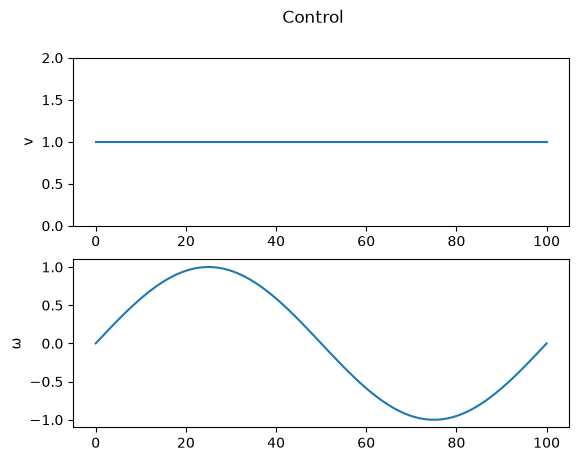

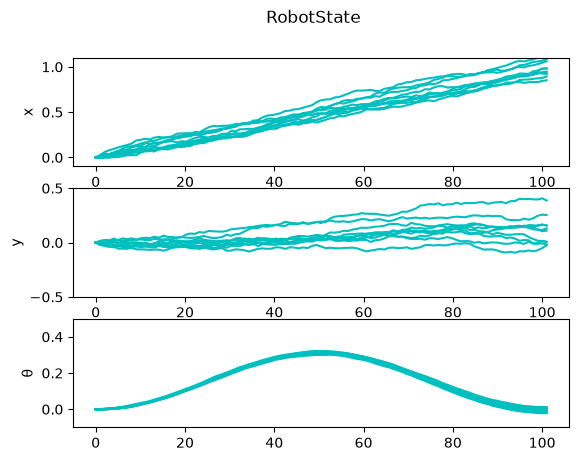

In [4]:
# Constants
num_rollouts = 10
num_steps = 100

# Define the dynamics class
dynamics = RobotDynamics()

# Define the control inputs
u_sequence = np.ones((dynamics.m, num_steps))
u_sequence[1,:] = np.sin(np.linspace(0, 2 * np.pi, num_steps))

# Define inital state
x0 = np.array([0, 0, 0])

# Rollouts dynamics
rollouts = dynamics.rollout(x0, u_sequence, num_rollouts)

# Plot control inputs
fig_ctrl, axs_ctrl = plt.subplots(nrows=dynamics.m)
ylabels_ctrl = ["v", "ω"]
ylims_ctrl = np.array([[0.0, 2.0],[-1.1, 1.1]])
for j in range(dynamics.m):
  axs_ctrl[j].plot(np.linspace(0, num_steps, num_steps), u_sequence[j, :])
  axs_ctrl[j].set_ylabel(ylabels_ctrl[j])
  axs_ctrl[j].set_ylim(ylims_ctrl[j, :])
fig_ctrl.suptitle("Control")

# Plot state trajectory rollouts
fig_state, axs_state = plt.subplots(nrows=dynamics.n)
ylabels_state = ["x", "y", "θ"]
ylims_state = np.array([[-0.1, 1.1], [-0.5, 0.5], [-0.1, 0.5]])
for i in range(num_rollouts):
  for j in range(dynamics.n):
    axs_state[j].plot(np.linspace(0, num_steps + 1, num_steps + 1), rollouts[i, j, :], c='c')
    axs_state[j].set_ylabel(ylabels_state[j])
    axs_state[j].set_ylim(ylims_state[j,:])
fig_state.suptitle("RobotState")
plt.show()